In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df=pd.read_csv("StudentsPerformance.csv")

In [5]:
#Construct grouped bar charts comparing average test scores across parental education
#levels andc. Plot box plots evaluating score variance between students who completed test
#preparation and those who did not. Create scatter plots and a correlation heatmap showing relationships between Math, Reading,
#and Writing scores. Deliver an educational equity and policy recommendations document.
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
parental_avg=df.groupby("parental level of education")[
["math score","reading score","writing score"]].mean()
print("/naverage score by parental eduction")
print(parental_avg)

/naverage score by parental eduction
                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


<function matplotlib.pyplot.show(close=None, block=None)>

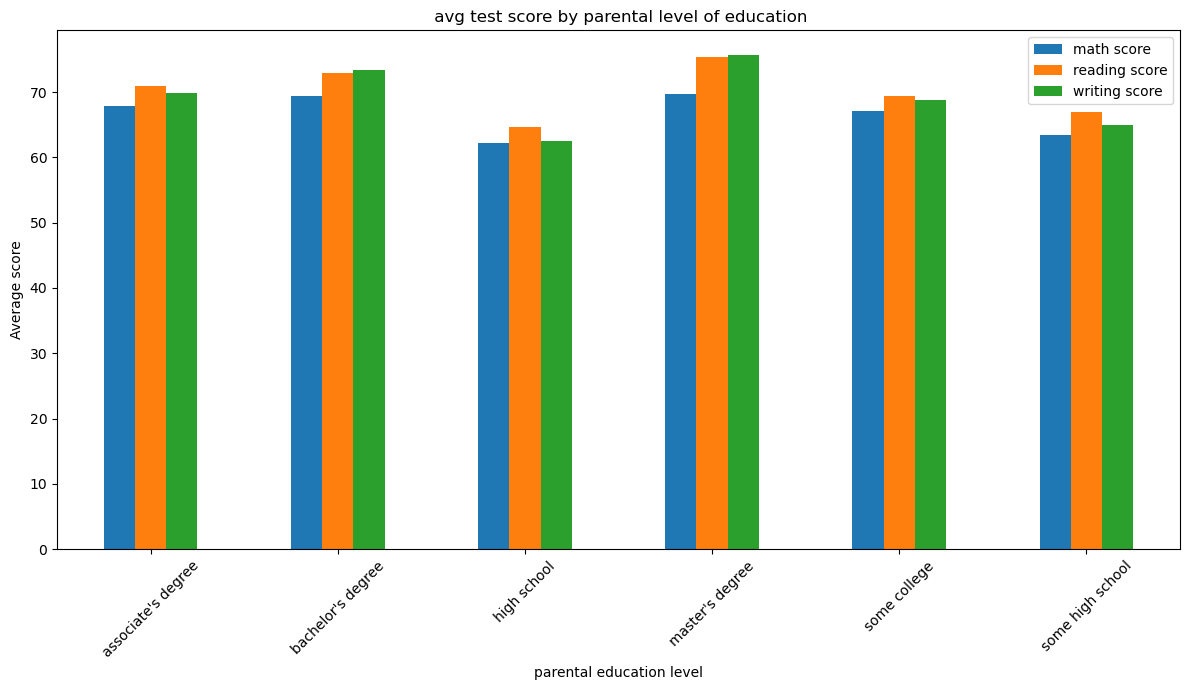

In [12]:
parental_avg.plot(
    kind="bar",
    figsize=(12,7)
)
plt.title(" avg test score by parental level of education")
plt.xlabel("parental education level")
plt.ylabel("Average score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show

In [13]:
lunch_avg=df.groupby("lunch")[
["math score","reading score","writing score"]].mean()
print("/avarage luch score")
print(lunch_avg)

/avarage luch score
              math score  reading score  writing score
lunch                                                 
free/reduced   58.921127      64.653521      63.022535
standard       70.034109      71.654264      70.823256


<function matplotlib.pyplot.show(close=None, block=None)>

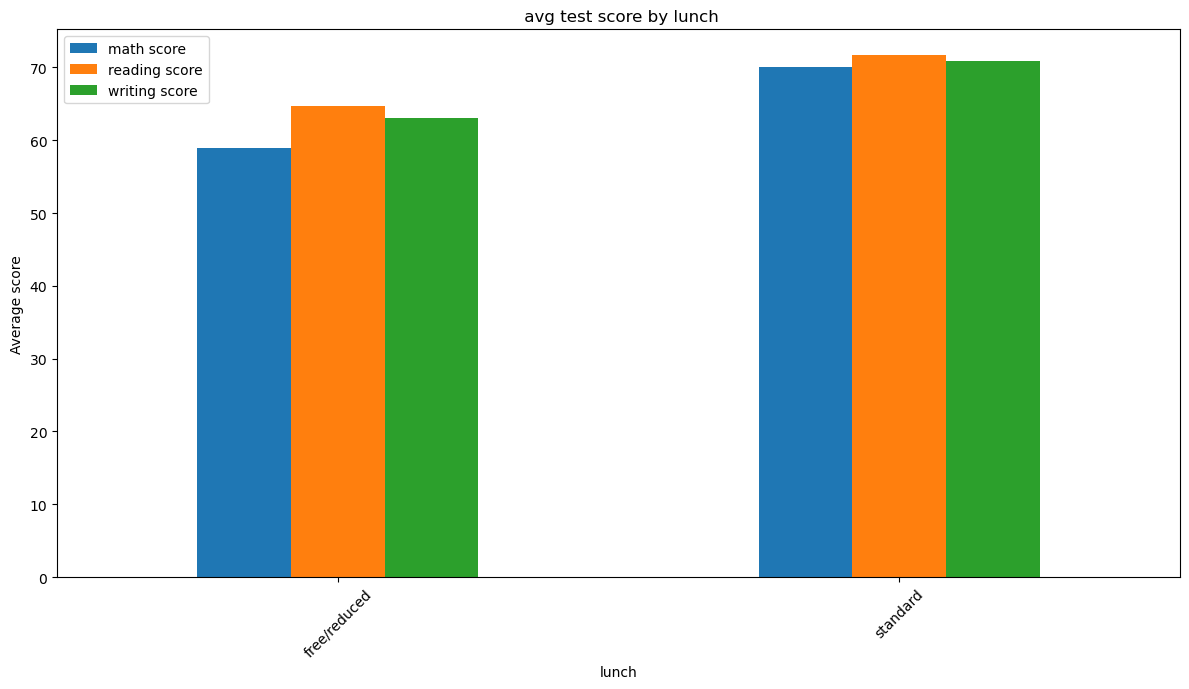

In [14]:
lunch_avg.plot(
    kind="bar",
    figsize=(12,7)
)
plt.title(" avg test score by lunch")
plt.xlabel("lunch")
plt.ylabel("Average score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show

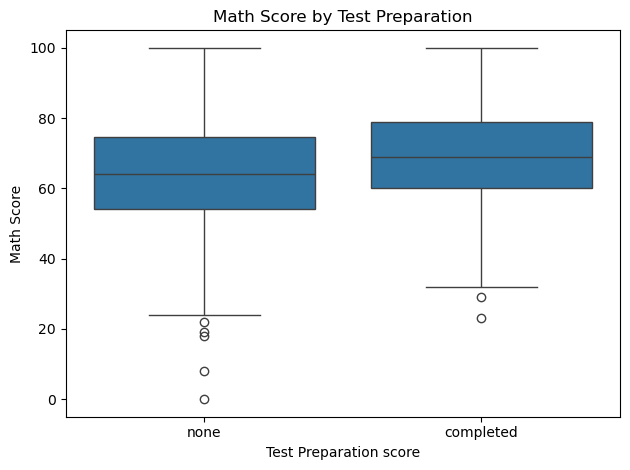

In [15]:
sns.boxplot(data=df, x="test preparation course", y="math score")
plt.title("Math Score by Test Preparation")
plt.xlabel("Test Preparation score")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()

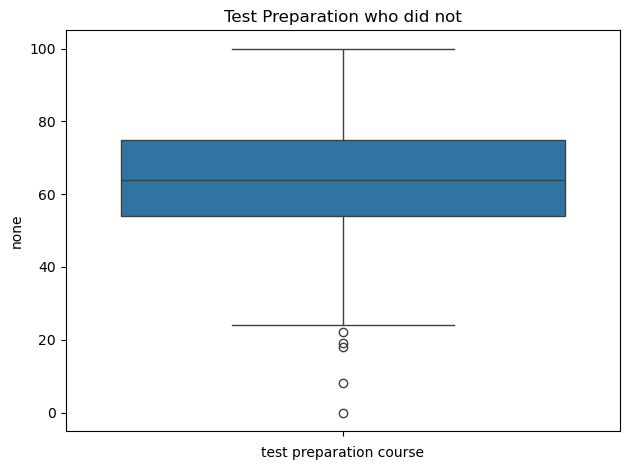

In [22]:
sns.boxplot(data=df[df["test preparation course"] == "none"],
    y="math score")
plt.title("Test Preparation who did not")
plt.xlabel("test preparation course")
plt.ylabel("none")
plt.tight_layout()
plt.show()

In [23]:
#Create scatter plots and a correlation heatmap showing relationships between Math, Reading,
#and Writing scores. Deliver an educational equity and policy recommendations document.

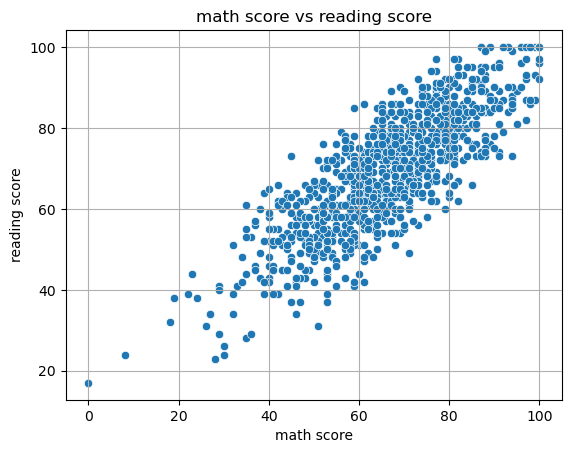

In [52]:
sns.scatterplot(x="math score",y="reading score",data=df)
plt.title("math score vs reading score")
plt.ylabel("reading score")
plt.xlabel("math score")
plt.grid(True)
plt.show()


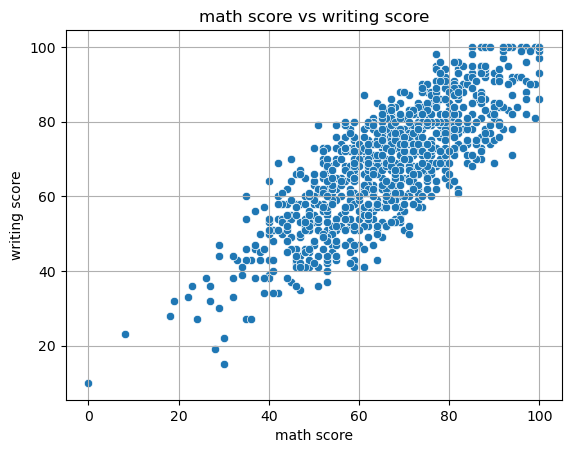

In [53]:
sns.scatterplot(x="math score",y="writing score",data=df)
plt.title("math score vs writing score")
plt.ylabel("writing score")
plt.xlabel("math score")
plt.grid(True)
plt.show()


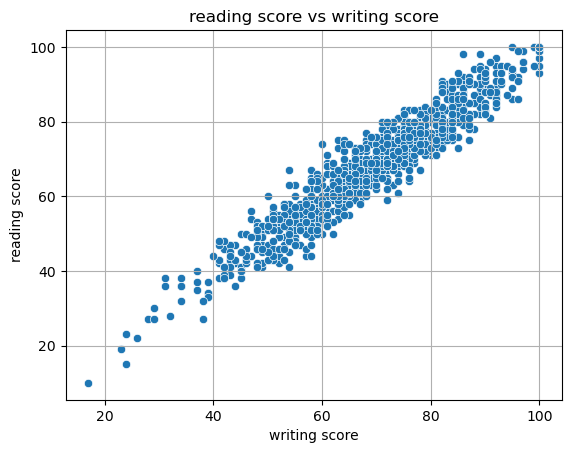

In [54]:
sns.scatterplot(x="reading score",y="writing score",data=df)
plt.title("reading score vs writing score")
plt.ylabel("reading score")
plt.xlabel("writing score")
plt.grid(True)
plt.show()


In [56]:
#hearmap

In [57]:
numaric_columns=["math score","reading score","writing score"]

In [55]:
numaric_columns

['math score', 'reading score', 'writing score']

In [26]:
correlation=df[numaric_columns].corr()

In [27]:
correlation

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

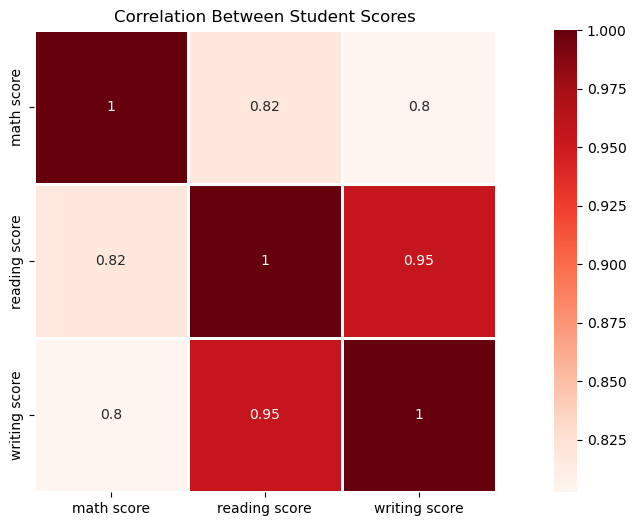

In [45]:
plt.figure(figsize=(15, 6))
sns.heatmap(correlation,
           annot=True,
           cmap="Reds",
           cbar=True,
           square=True,
           linewidth=2)
plt.title("Correlation Between Student Scores")
plt.show            